In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pandas.plotting import lag_plot
import calendar

# Load dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
data = pd.read_csv(url, parse_dates=['Month'], index_col='Month')
data.columns = ['Passengers']
print(data.head())

            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


### 1. Line Plot


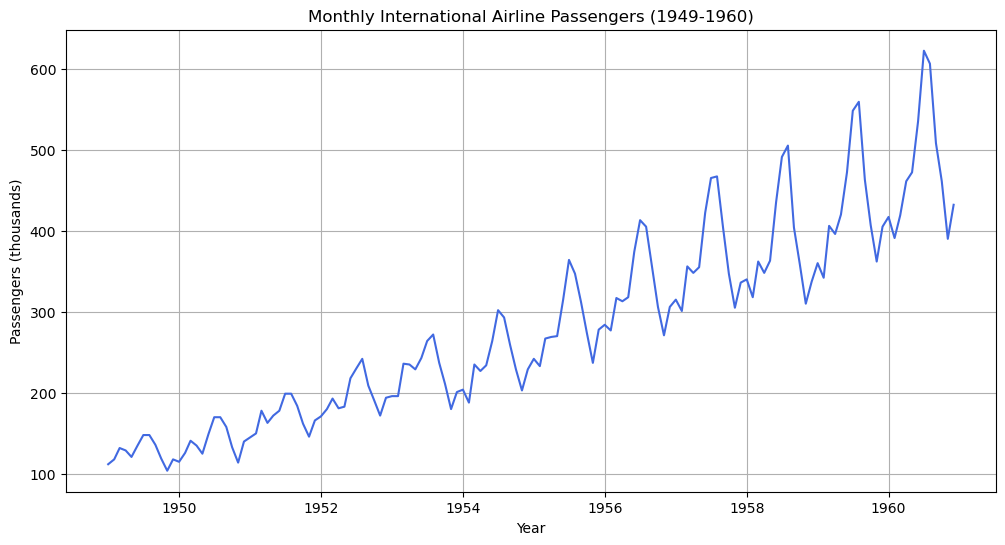

In [7]:
plt.figure(figsize=(12, 6))
plt.plot(data.index, data['Passengers'], color='royalblue')
plt.title('Monthly International Airline Passengers (1949-1960)')
plt.xlabel('Year')
plt.ylabel('Passengers (thousands)')
plt.grid(True)
plt.show()

### 2. Seasonal Decomposition


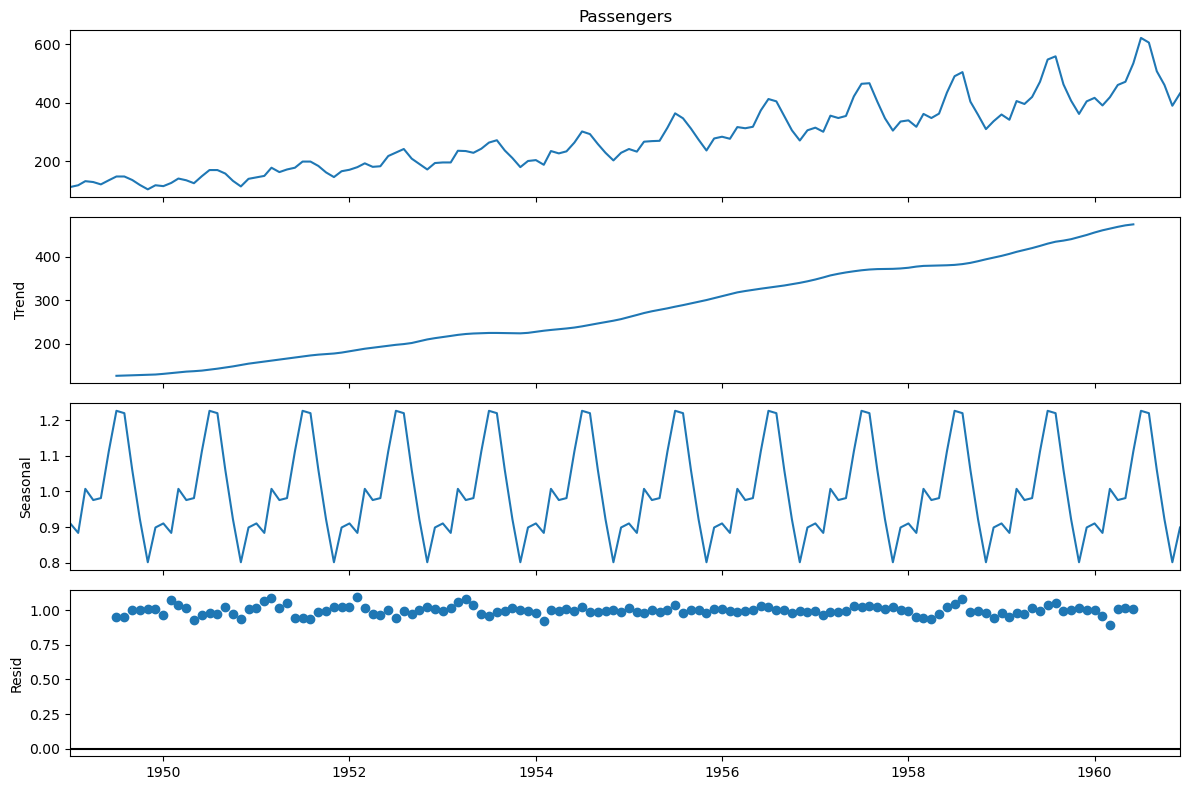

In [8]:
decomposition = seasonal_decompose(data['Passengers'], model='multiplicative')
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

### 3. Bar Chart (Monthly Averages)


<Figure size 1000x500 with 0 Axes>

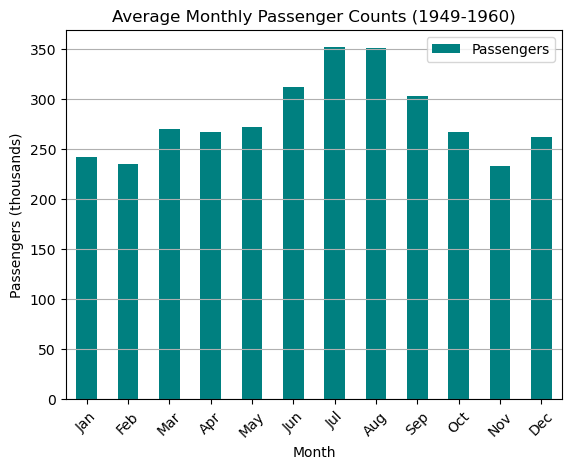

In [9]:
monthly_avg = data.groupby(data.index.month).mean()
monthly_avg.index = [calendar.month_abbr[i] for i in monthly_avg.index]

plt.figure(figsize=(10, 5))
monthly_avg.plot(kind='bar', color='teal')
plt.title('Average Monthly Passenger Counts (1949-1960)')
plt.xlabel('Month')
plt.ylabel('Passengers (thousands)')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

### 4. Calendar Heatmap


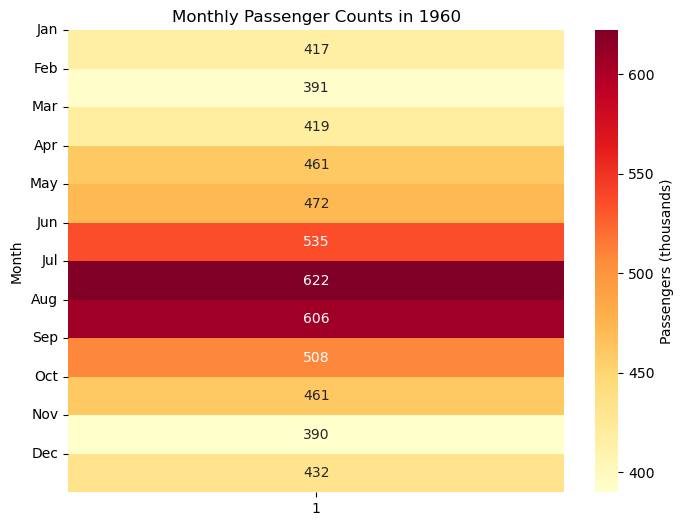

In [14]:
# Prepare data for heatmap (using 1960 as example year)
heatmap_data = data.loc['1960'].copy()
heatmap_data = heatmap_data.reset_index()
heatmap_data['Month'] = heatmap_data['Month'].dt.month
heatmap_data['Day'] = 1  # Dummy day for pivot
heatmap_pivot = heatmap_data.pivot(index="Month", columns="Day", values="Passengers")

plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_pivot, cmap="YlOrRd", annot=True, fmt=".0f", 
            cbar_kws={'label': 'Passengers (thousands)'})
plt.title('Monthly Passenger Counts in 1960')
plt.xlabel('')
plt.ylabel('Month')
plt.yticks(ticks=range(12), labels=[calendar.month_abbr[i+1] for i in range(12)], rotation=0)
plt.show()

### 5. Autocorrelation Plot


<Figure size 1200x500 with 0 Axes>

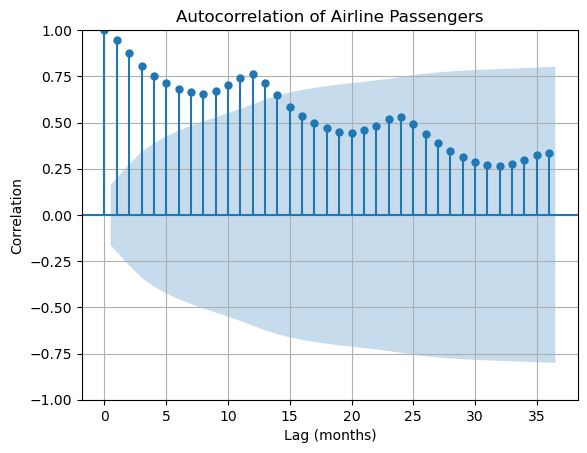

In [15]:
plt.figure(figsize=(12, 5))
plot_acf(data['Passengers'], lags=36, alpha=0.05)
plt.title('Autocorrelation of Airline Passengers')
plt.xlabel('Lag (months)')
plt.ylabel('Correlation')
plt.grid(True)
plt.show()

### 6. Lag Plot (Lag-12)


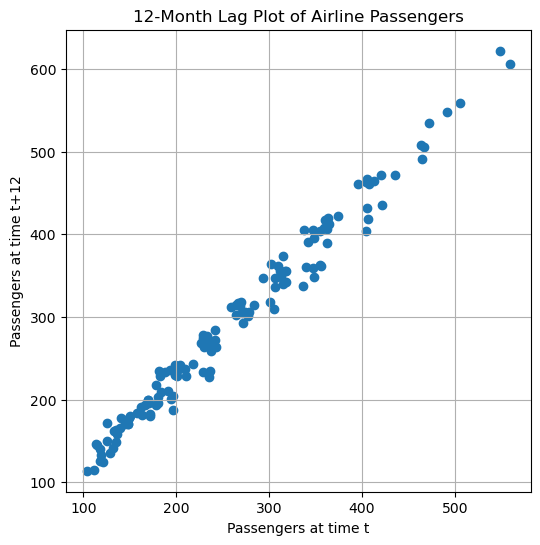

In [16]:
plt.figure(figsize=(6, 6))
lag_plot(data['Passengers'], lag=12)
plt.title('12-Month Lag Plot of Airline Passengers')
plt.xlabel('Passengers at time t')
plt.ylabel('Passengers at time t+12')
plt.grid(True)
plt.show()